# Analysis of Product Sales

Obtain information about the product sales of the various retailer types in UTC offset. Display the average amount of sales that occurred in each time zone

In [2]:
import pandas as pd
import pytz
from datetime import datetime
from matplotlib import pyplot as plt

data = pd.read_csv('Sales-products-tz-mod.csv', index_col='SaleID')
sales_data = data.copy()
sales_data.head(20)

,RetailerCountry,RetailerType,Product,Sales Revenue ($),DateOfSale,TimeOfSale,TimeZone
SaleID,,,,,,,
SaleID_1,United States,Outdoors Shop,TrailChef Deluxe Cook Set,200.00,06/01/2020,23:20:56,EST
SaleID_2,United States,Outdoors Shop,TrailChef Double Flame,7.00,05/02/2020,17:27:08,EST
SaleID_3,United States,Outdoors Shop,Star Dome,20.00,30/10/2020,09:04:43,EST
SaleID_4,United States,Outdoors Shop,Star Gazer 2,40.00,13/11/2020,04:25:06,EST
SaleID_5,Italy,Outdoors Shop,Canyon Mule Carryall,150.50,06/12/2020,11:15:47,CET
SaleID_6,Italy,Outdoors Shop,Firefly 4,1300.00,07/06/2020,01:54:41,CET
SaleID_7,United Kingdom,Outdoors Shop,Husky Rope 50,270.00,27/12/2020,02:07:28,GMT
SaleID_8,United Kingdom,Outdoors Shop,Granite Signal Mirror,499.99,15/09/2020,11:44:57,GMT
SaleID_9,United Kingdom,Outdoors Shop,Granite Carabiner,32.00,23/09/2020,01:40:29,GMT


In [3]:
sales_data[['DateOfSale', 'TimeOfSale', 'TimeZone']].head()

,DateOfSale,TimeOfSale,TimeZone
SaleID,,,
SaleID_1,06/01/2020,23:20:56,EST
SaleID_2,05/02/2020,17:27:08,EST
SaleID_3,30/10/2020,09:04:43,EST
SaleID_4,13/11/2020,04:25:06,EST
SaleID_5,06/12/2020,11:15:47,CET


In [4]:
#concatenate the DateOfSale and TimeOfSale columns
date_and_time = sales_data['DateOfSale'] +" "+ sales_data['TimeOfSale']
date_and_time

SaleID
SaleID_1      06/01/2020 23:20:56
SaleID_2      05/02/2020 17:27:08
SaleID_3      30/10/2020 09:04:43
SaleID_4      13/11/2020 04:25:06
SaleID_5      06/12/2020 11:15:47
                     ...         
SaleID_96     23/07/2019 12:30:03
SaleID_97     03/01/2019 01:39:14
SaleID_98     14/02/2019 21:29:35
SaleID_99     19/06/2020 11:16:19
SaleID_100    25/05/2019 15:51:41
Length: 100, dtype: str

In [5]:
#Convert the concatenated date and time values into a datetime object in a new column in the sales_data dataframe
sales_data['MOS'] = pd.to_datetime(date_and_time, format = '%d/%m/%Y %H:%M:%S')
sales_data.head()

,RetailerCountry,RetailerType,Product,Sales Revenue ($),DateOfSale,TimeOfSale,TimeZone,MOS
SaleID,,,,,,,,
SaleID_1,United States,Outdoors Shop,TrailChef Deluxe Cook Set,200.0,06/01/2020,23:20:56,EST,2020-01-06 23:20:56
SaleID_2,United States,Outdoors Shop,TrailChef Double Flame,7.0,05/02/2020,17:27:08,EST,2020-02-05 17:27:08
SaleID_3,United States,Outdoors Shop,Star Dome,20.0,30/10/2020,09:04:43,EST,2020-10-30 09:04:43
SaleID_4,United States,Outdoors Shop,Star Gazer 2,40.0,13/11/2020,04:25:06,EST,2020-11-13 04:25:06
SaleID_5,Italy,Outdoors Shop,Canyon Mule Carryall,150.5,06/12/2020,11:15:47,CET,2020-12-06 11:15:47


In [6]:
#Drop the DateofSale and TimeOfSale columns since they are now merged into the new column MOS and new table called sales_data_2
sales_data_2 = sales_data.drop(['DateOfSale','TimeOfSale'], axis = 1) #axis = 0 operate on rows; axis = 1 operate on columns
sales_data_2.head()

,RetailerCountry,RetailerType,Product,Sales Revenue ($),TimeZone,MOS
SaleID,,,,,,
SaleID_1,United States,Outdoors Shop,TrailChef Deluxe Cook Set,200.0,EST,2020-01-06 23:20:56
SaleID_2,United States,Outdoors Shop,TrailChef Double Flame,7.0,EST,2020-02-05 17:27:08
SaleID_3,United States,Outdoors Shop,Star Dome,20.0,EST,2020-10-30 09:04:43
SaleID_4,United States,Outdoors Shop,Star Gazer 2,40.0,EST,2020-11-13 04:25:06
SaleID_5,Italy,Outdoors Shop,Canyon Mule Carryall,150.5,CET,2020-12-06 11:15:47


In [7]:
# View the Olson timezone database
pytz.all_timezones

['Africa/Abidjan', 'Africa/Accra', 'Africa/Addis_Ababa', 'Africa/Algiers', 'Africa/Asmara', 'Africa/Asmera', 'Africa/Bamako', 'Africa/Bangui', 'Africa/Banjul', 'Africa/Bissau', 'Africa/Blantyre', 'Africa/Brazzaville', 'Africa/Bujumbura', 'Africa/Cairo', 'Africa/Casablanca', 'Africa/Ceuta', 'Africa/Conakry', 'Africa/Dakar', 'Africa/Dar_es_Salaam', 'Africa/Djibouti', 'Africa/Douala', 'Africa/El_Aaiun', 'Africa/Freetown', 'Africa/Gaborone', 'Africa/Harare', 'Africa/Johannesburg', 'Africa/Juba', 'Africa/Kampala', 'Africa/Khartoum', 'Africa/Kigali', 'Africa/Kinshasa', 'Africa/Lagos', 'Africa/Libreville', 'Africa/Lome', 'Africa/Luanda', 'Africa/Lubumbashi', 'Africa/Lusaka', 'Africa/Malabo', 'Africa/Maputo', 'Africa/Maseru', 'Africa/Mbabane', 'Africa/Mogadishu', 'Africa/Monrovia', 'Africa/Nairobi', 'Africa/Ndjamena', 'Africa/Niamey', 'Africa/Nouakchott', 'Africa/Ouagadougou', 'Africa/Porto-Novo', 'Africa/Sao_Tome', 'Africa/Timbuktu', 'Africa/Tripoli', 'Africa/Tunis', 'Africa/Windhoek', 'Ameri

In [8]:
# Want to check whether the timezones in the sales_data dataframe are in the Olson database
#sales_data['TimeZone'].unique()
for i in sales_data_2['TimeZone'].unique():
    if i in pytz.all_timezones:
        print(True)
    else:
        print(False)

True
True
True
True
False
True


In [9]:
# Since Singapore (not SGT) is in the Olson list then replace SGT with Singapore
sales_data_2.loc[:, 'TimeZone'] = sales_data_2.loc[:, 'TimeZone'].replace({'SGT': 'Singapore'})

# Check
sales_data_2['TimeZone'].unique()

<ArrowStringArray>
['EST', 'CET', 'GMT', 'EET', 'Singapore', 'Australia/West']
Length: 6, dtype: str

In [10]:
# Select rows where TimeZone is 'Singapore'
sales_data_2[sales_data_2['TimeZone'] == 'Singapore']

,RetailerCountry,RetailerType,Product,Sales Revenue ($),TimeZone,MOS
SaleID,,,,,,
SaleID_18,Singapore,Outdoors Shop,Granite Pulley,19.00,Singapore,2019-01-02 01:32:09
SaleID_19,Singapore,Outdoors Shop,Firefly Climbing Lamp,23.45,Singapore,2019-02-20 07:07:10
SaleID_20,Singapore,Outdoors Shop,Granite Ice,65.00,Singapore,2019-04-10 10:27:26
SaleID_21,Singapore,Outdoors Shop,Mountain Man Analog,10.00,Singapore,2019-07-10 05:20:29
SaleID_22,Singapore,Outdoors Shop,Mountain Man Digital,12.00,Singapore,2020-05-03 09:54:41
SaleID_23,Singapore,Outdoors Shop,Mountain Man Deluxe,19.00,Singapore,2019-07-25 06:51:57
SaleID_81,Singapore,Warehouse Store,EverGlow Kerosene,23.06,Singapore,2019-11-10 12:50:36
SaleID_82,Singapore,Outdoors Shop,TX,50.00,Singapore,2019-09-25 19:48:39


In [11]:
# Turn off Python's row and column truncation
pd.options.display.max_rows = None
pd.options.display.max_columns = None
sales_data_2

,RetailerCountry,RetailerType,Product,Sales Revenue ($),TimeZone,MOS
SaleID,,,,,,
SaleID_1,United States,Outdoors Shop,TrailChef Deluxe Cook Set,200.00,EST,2020-01-06 23:20:56
SaleID_2,United States,Outdoors Shop,TrailChef Double Flame,7.00,EST,2020-02-05 17:27:08
SaleID_3,United States,Outdoors Shop,Star Dome,20.00,EST,2020-10-30 09:04:43
SaleID_4,United States,Outdoors Shop,Star Gazer 2,40.00,EST,2020-11-13 04:25:06
SaleID_5,Italy,Outdoors Shop,Canyon Mule Carryall,150.50,CET,2020-12-06 11:15:47
SaleID_6,Italy,Outdoors Shop,Firefly 4,1300.00,CET,2020-06-07 01:54:41
SaleID_7,United Kingdom,Outdoors Shop,Husky Rope 50,270.00,GMT,2020-12-27 02:07:28
SaleID_8,United Kingdom,Outdoors Shop,Granite Signal Mirror,499.99,GMT,2020-09-15 11:44:57
SaleID_9,United Kingdom,Outdoors Shop,Granite Carabiner,32.00,GMT,2020-09-23 01:40:29


In [12]:
# using iloc to give the value of the first row of the MOS column
sales_data_2['MOS'].iloc[0]

Timestamp('2020-01-06 23:20:56')

In [13]:
# Make the date in the first row of the MOS column timezone aware
sales_data_2['MOS'].iloc[0].tz_localize(sales_data_2['TimeZone'].iloc[0])

Timestamp('2020-01-06 23:20:56-0500', tz='EST')

In [14]:
# Create timezone aware dates for all the dates in the MOS column

list_mos_timestamps = [] #Initiatise list to store timezone aware dates

# raise an exception in case of amibigiuos or nonexistent dates
for i in range(len(sales_data_2)):
    list_mos_timestamps.append(pd.to_datetime(sales_data_2['MOS'].iloc[i].tz_localize(sales_data_2['TimeZone'].iloc[i], ambiguous='raise', nonexistent='raise')))

# Use list slicing to display the first 10 rows of the data set
list_mos_timestamps[:10]

# Display all data set
list_mos_timestamps


[Timestamp('2020-01-06 23:20:56-0500', tz='EST'),
 Timestamp('2020-02-05 17:27:08-0500', tz='EST'),
 Timestamp('2020-10-30 09:04:43-0500', tz='EST'),
 Timestamp('2020-11-13 04:25:06-0500', tz='EST'),
 Timestamp('2020-12-06 11:15:47+0100', tz='CET'),
 Timestamp('2020-06-07 01:54:41+0200', tz='CET'),
 Timestamp('2020-12-27 02:07:28+0000', tz='GMT'),
 Timestamp('2020-09-15 11:44:57+0000', tz='GMT'),
 Timestamp('2020-09-23 01:40:29+0000', tz='GMT'),
 Timestamp('2020-06-24 18:43:04+0200', tz='CET'),
 Timestamp('2019-05-19 02:12:30+0200', tz='CET'),
 Timestamp('2019-04-05 07:38:10-0500', tz='EST'),
 Timestamp('2020-01-24 08:51:28-0500', tz='EST'),
 Timestamp('2019-12-07 08:14:53-0500', tz='EST'),
 Timestamp('2020-01-13 05:32:40-0500', tz='EST'),
 Timestamp('2020-11-26 10:17:48+0200', tz='EET'),
 Timestamp('2020-01-23 19:36:25+0200', tz='EET'),
 Timestamp('2019-01-02 01:32:09+0800', tz='Singapore'),
 Timestamp('2019-02-20 07:07:10+0800', tz='Singapore'),
 Timestamp('2019-04-10 10:27:26+0800',

In [15]:
# Obtaining different values from the time aware list of dattime rows

# Get date time in string format to the specified format
print(list_mos_timestamps[0].strftime('%Y-%m-%d %H:%M:%S'))

# Get information about the UTC offset object
print(list_mos_timestamps[0].strftime('%z'))

# Convert the offset into a numeric value
print(float(list_mos_timestamps[0].strftime('%z'))/100)

# Get the date part of the datetime object
print(list_mos_timestamps[0].date())

# Get the time part of the datetime object
print(list_mos_timestamps[0].time())

# Get the relevant offset of the datetime object
print(list_mos_timestamps[0].utcoffset())

# Get the relevant offset (in seconds) of the datetime object
print(list_mos_timestamps[0].utcoffset().total_seconds()/3600)

2020-01-06 23:20:56
-0500
-5.0
2020-01-06
23:20:56
-1 day, 19:00:00
-5.0


In [16]:
# Use a list comprehension to get the UTC offset for all the date values and put in new column in data frame
sales_data_2['OffsetUTC'] = [list_mos_timestamps[i].utcoffset().total_seconds() / 3600 for i in range(len(sales_data_2))]

sales_data_2.head()

,RetailerCountry,RetailerType,Product,Sales Revenue ($),TimeZone,MOS,OffsetUTC
SaleID,,,,,,,
SaleID_1,United States,Outdoors Shop,TrailChef Deluxe Cook Set,200.0,EST,2020-01-06 23:20:56,-5.0
SaleID_2,United States,Outdoors Shop,TrailChef Double Flame,7.0,EST,2020-02-05 17:27:08,-5.0
SaleID_3,United States,Outdoors Shop,Star Dome,20.0,EST,2020-10-30 09:04:43,-5.0
SaleID_4,United States,Outdoors Shop,Star Gazer 2,40.0,EST,2020-11-13 04:25:06,-5.0
SaleID_5,Italy,Outdoors Shop,Canyon Mule Carryall,150.5,CET,2020-12-06 11:15:47,1.0


In [17]:
# Reorder the columns in the data frame
column_names_reordered = ['RetailerCountry', 'MOS', 'TimeZone', 'OffsetUTC', 'RetailerType', 'Product', 'Sales Revenue ($)']
sales_data_2 = sales_data_2[column_names_reordered]
sales_data_2.head()

,RetailerCountry,MOS,TimeZone,OffsetUTC,RetailerType,Product,Sales Revenue ($)
SaleID,,,,,,,
SaleID_1,United States,2020-01-06 23:20:56,EST,-5.0,Outdoors Shop,TrailChef Deluxe Cook Set,200.0
SaleID_2,United States,2020-02-05 17:27:08,EST,-5.0,Outdoors Shop,TrailChef Double Flame,7.0
SaleID_3,United States,2020-10-30 09:04:43,EST,-5.0,Outdoors Shop,Star Dome,20.0
SaleID_4,United States,2020-11-13 04:25:06,EST,-5.0,Outdoors Shop,Star Gazer 2,40.0
SaleID_5,Italy,2020-12-06 11:15:47,CET,1.0,Outdoors Shop,Canyon Mule Carryall,150.5


In [18]:
# Do a count by TimeZone and OffsetUTC
sales_data_2.groupby(['TimeZone', 'OffsetUTC']).count()

RetailerCountry  MOS  RetailerType  Product  \
TimeZone       OffsetUTC                                                
Australia/West  8.0                    17   17            17       17   
CET             1.0                     5    5             5        5   
                2.0                    11   11            11       11   
EET             2.0                     4    4             4        4   
                3.0                     4    4             4        4   
EST            -5.0                    40   40            40       40   
GMT             0.0                    11   11            11       11   
Singapore       8.0                     8    8             8        8   

                          Sales Revenue ($)  
TimeZone       OffsetUTC                     
Australia/West  8.0                      17  
CET             1.0                       5  
                2.0                      11  
EET             2.0                       4  
                3.0                       4  
EST            -5.0                      40  
GMT             0.0                      11  
Singapore       8.0                       8

In [19]:
# Filter for the CET TimeZone
sales_data_2[sales_data_2['TimeZone']=='CET'].sort_values('OffsetUTC')

,RetailerCountry,MOS,TimeZone,OffsetUTC,RetailerType,Product,Sales Revenue ($)
SaleID,,,,,,,
SaleID_5,Italy,2020-12-06 11:15:47,CET,1.0,Outdoors Shop,Canyon Mule Carryall,150.50
SaleID_31,Germany,2019-02-24 19:16:17,CET,1.0,Online Retailer,Firefly Climbing Lamp,23.00
SaleID_73,Switzerland,2019-03-26 09:52:36,CET,1.0,Mall,Course Pro Umbrella,100.32
SaleID_75,Switzerland,2019-03-14 22:25:10,CET,1.0,Mall,Course Pro Gloves,40.50
SaleID_83,Austria,2020-03-10 21:42:37,CET,1.0,Outdoors Shop,Legend,641.00
SaleID_10,Italy,2020-06-24 18:43:04,CET,2.0,Outdoors Shop,Granite Grip,220.00
SaleID_11,Italy,2019-05-19 02:12:30,CET,2.0,Outdoors Shop,Granite Axe,49.99
SaleID_6,Italy,2020-06-07 01:54:41,CET,2.0,Outdoors Shop,Firefly 4,1300.00
SaleID_72,Switzerland,2019-05-30 06:36:09,CET,2.0,Mall,Course Pro Golf and Tee Set,25.00


In [20]:
# Sorting the MOS column would not be appropriate as they are not UTC formatted so would give a misleading order of chronology so it is necessary to 
# convert to UTC
sales_data_2['MOS-UTC'] = [pd.to_datetime(sales_data['MOS'].iloc[i]).tz_localize(sales_data_2['TimeZone'].iloc[i]).tz_convert('UTC')
                           for i in range(len(sales_data_2))]

In [21]:
# The new sales table table with UTC formatted MOS column called MOS-UTC
sales_data_2.head()

,RetailerCountry,MOS,TimeZone,OffsetUTC,RetailerType,Product,Sales Revenue ($),MOS-UTC
SaleID,,,,,,,,
SaleID_1,United States,2020-01-06 23:20:56,EST,-5.0,Outdoors Shop,TrailChef Deluxe Cook Set,200.0,2020-01-07 04:20:56+00:00
SaleID_2,United States,2020-02-05 17:27:08,EST,-5.0,Outdoors Shop,TrailChef Double Flame,7.0,2020-02-05 22:27:08+00:00
SaleID_3,United States,2020-10-30 09:04:43,EST,-5.0,Outdoors Shop,Star Dome,20.0,2020-10-30 14:04:43+00:00
SaleID_4,United States,2020-11-13 04:25:06,EST,-5.0,Outdoors Shop,Star Gazer 2,40.0,2020-11-13 09:25:06+00:00
SaleID_5,Italy,2020-12-06 11:15:47,CET,1.0,Outdoors Shop,Canyon Mule Carryall,150.5,2020-12-06 10:15:47+00:00


In [22]:
# Re-order the column to put MOS-UTC first
column_names_reordered = ['RetailerCountry', 'MOS-UTC', 'MOS', 'TimeZone', 'OffsetUTC', 'RetailerType', 'Product', 'Sales Revenue ($)']
sales_data_2 = sales_data_2[column_names_reordered]


In [23]:
# The new sales data table showing the chronological order of sales according to UTC and not local time
sales_data_2.head()

,RetailerCountry,MOS-UTC,MOS,TimeZone,OffsetUTC,RetailerType,Product,Sales Revenue ($)
SaleID,,,,,,,,
SaleID_1,United States,2020-01-07 04:20:56+00:00,2020-01-06 23:20:56,EST,-5.0,Outdoors Shop,TrailChef Deluxe Cook Set,200.0
SaleID_2,United States,2020-02-05 22:27:08+00:00,2020-02-05 17:27:08,EST,-5.0,Outdoors Shop,TrailChef Double Flame,7.0
SaleID_3,United States,2020-10-30 14:04:43+00:00,2020-10-30 09:04:43,EST,-5.0,Outdoors Shop,Star Dome,20.0
SaleID_4,United States,2020-11-13 09:25:06+00:00,2020-11-13 04:25:06,EST,-5.0,Outdoors Shop,Star Gazer 2,40.0
SaleID_5,Italy,2020-12-06 10:15:47+00:00,2020-12-06 11:15:47,CET,1.0,Outdoors Shop,Canyon Mule Carryall,150.5


In [24]:
# Sales data sorted in chronological order using MOS-UTC column
# Note the difference between the MOS_UTC and MOS datetime values for the first row
sales_data_2.sort_values(['MOS-UTC'])

,RetailerCountry,MOS-UTC,MOS,TimeZone,OffsetUTC,RetailerType,Product,Sales Revenue ($)
SaleID,,,,,,,,
SaleID_18,Singapore,2019-01-01 17:32:09+00:00,2019-01-02 01:32:09,Singapore,8.0,Outdoors Shop,Granite Pulley,19.00
SaleID_97,Australia,2019-01-02 17:39:14+00:00,2019-01-03 01:39:14,Australia/West,8.0,Department Store,Firefly Mapreader,1200.00
SaleID_53,Canada,2019-01-03 20:40:25+00:00,2019-01-03 15:40:25,EST,-5.0,Sports Store,Opera Vision,450.00
SaleID_55,Canada,2019-01-11 00:37:17+00:00,2019-01-10 19:37:17,EST,-5.0,Sports Store,Glacier Basic,140.00
SaleID_37,Canada,2019-01-11 19:24:52+00:00,2019-01-11 14:24:52,EST,-5.0,Outdoors Shop,Capri,35.00
SaleID_33,Canada,2019-01-16 18:33:16+00:00,2019-01-16 13:33:16,EST,-5.0,Outdoors Shop,Venue,110.00
SaleID_87,Australia,2019-01-18 20:29:44+00:00,2019-01-19 04:29:44,Australia/West,8.0,Sports Store,Star Peg,37.85
SaleID_60,Canada,2019-02-02 04:10:36+00:00,2019-02-01 23:10:36,EST,-5.0,Outdoors Shop,Polar Sun,32.00
SaleID_98,Australia,2019-02-14 13:29:35+00:00,2019-02-14 21:29:35,Australia/West,8.0,Discount Retailer,Polar Sun,32.00


In [25]:
# What is the average offset?
sales_data_2.groupby('TimeZone').mean(numeric_only=True)

,OffsetUTC,Sales Revenue ($)
TimeZone,,
Australia/West,8.0000,273.105882
CET,1.6875,415.710000
EET,2.5000,586.687500
EST,-5.0000,230.385500
GMT,0.0000,115.137273
Singapore,8.0000,27.688750


In [26]:
# An overview of how many sales have occured in each time zone
# Also indicates no missing data given by the same number across rows
sales_data_2.groupby('TimeZone').count()

,RetailerCountry,MOS-UTC,MOS,OffsetUTC,RetailerType,Product,Sales Revenue ($)
TimeZone,,,,,,,
Australia/West,17,17,17,17,17,17,17
CET,16,16,16,16,16,16,16
EET,8,8,8,8,8,8,8
EST,40,40,40,40,40,40,40
GMT,11,11,11,11,11,11,11
Singapore,8,8,8,8,8,8,8


In [27]:
# Group by using more thant 2 columns
sales_data_2.groupby(['TimeZone', 'OffsetUTC']).count()

RetailerCountry  MOS-UTC  MOS  RetailerType  \
TimeZone       OffsetUTC                                                
Australia/West  8.0                    17       17   17            17   
CET             1.0                     5        5    5             5   
                2.0                    11       11   11            11   
EET             2.0                     4        4    4             4   
                3.0                     4        4    4             4   
EST            -5.0                    40       40   40            40   
GMT             0.0                    11       11   11            11   
Singapore       8.0                     8        8    8             8   

                          Product  Sales Revenue ($)  
TimeZone       OffsetUTC                              
Australia/West  8.0            17                 17  
CET             1.0             5                  5  
                2.0            11                 11  
EET             2.0             4                  4  
                3.0             4                  4  
EST            -5.0            40                 40  
GMT             0.0            11                 11  
Singapore       8.0             8                  8

In [28]:
# Sort the data frame from highest number of sales to lowest number of sales
sales_data_2.groupby(['TimeZone', 'OffsetUTC']).count().sort_values('Product', ascending = False)

RetailerCountry  MOS-UTC  MOS  RetailerType  \
TimeZone       OffsetUTC                                                
EST            -5.0                    40       40   40            40   
Australia/West  8.0                    17       17   17            17   
GMT             0.0                    11       11   11            11   
CET             2.0                    11       11   11            11   
Singapore       8.0                     8        8    8             8   
CET             1.0                     5        5    5             5   
EET             2.0                     4        4    4             4   
                3.0                     4        4    4             4   

                          Product  Sales Revenue ($)  
TimeZone       OffsetUTC                              
EST            -5.0            40                 40  
Australia/West  8.0            17                 17  
GMT             0.0            11                 11  
CET             2.0            11                 11  
Singapore       8.0             8                  8  
CET             1.0             5                  5  
EET             2.0             4                  4  
                3.0             4                  4

In [29]:
sales_data_2.head()

,RetailerCountry,MOS-UTC,MOS,TimeZone,OffsetUTC,RetailerType,Product,Sales Revenue ($)
SaleID,,,,,,,,
SaleID_1,United States,2020-01-07 04:20:56+00:00,2020-01-06 23:20:56,EST,-5.0,Outdoors Shop,TrailChef Deluxe Cook Set,200.0
SaleID_2,United States,2020-02-05 22:27:08+00:00,2020-02-05 17:27:08,EST,-5.0,Outdoors Shop,TrailChef Double Flame,7.0
SaleID_3,United States,2020-10-30 14:04:43+00:00,2020-10-30 09:04:43,EST,-5.0,Outdoors Shop,Star Dome,20.0
SaleID_4,United States,2020-11-13 09:25:06+00:00,2020-11-13 04:25:06,EST,-5.0,Outdoors Shop,Star Gazer 2,40.0
SaleID_5,Italy,2020-12-06 10:15:47+00:00,2020-12-06 11:15:47,CET,1.0,Outdoors Shop,Canyon Mule Carryall,150.5


In [30]:
# reset_index() is pandas method that moves the current index back into a regular column and creates a new default integer index.
sales_data_2_viz = sales_data_2.reset_index()
sales_data_2_viz.head()

,SaleID,RetailerCountry,MOS-UTC,MOS,TimeZone,OffsetUTC,RetailerType,Product,Sales Revenue ($)
0,SaleID_1,United States,2020-01-07 04:20:56+00:00,2020-01-06 23:20:56,EST,-5.0,Outdoors Shop,TrailChef Deluxe Cook Set,200.0
1,SaleID_2,United States,2020-02-05 22:27:08+00:00,2020-02-05 17:27:08,EST,-5.0,Outdoors Shop,TrailChef Double Flame,7.0
2,SaleID_3,United States,2020-10-30 14:04:43+00:00,2020-10-30 09:04:43,EST,-5.0,Outdoors Shop,Star Dome,20.0
3,SaleID_4,United States,2020-11-13 09:25:06+00:00,2020-11-13 04:25:06,EST,-5.0,Outdoors Shop,Star Gazer 2,40.0
4,SaleID_5,Italy,2020-12-06 10:15:47+00:00,2020-12-06 11:15:47,CET,1.0,Outdoors Shop,Canyon Mule Carryall,150.5


In [31]:
# set the new dataframe index to MOS-UTC and sort ascendingly
sales_data_2_viz = sales_data_2_viz.set_index('MOS-UTC').sort_index()
sales_data_2_viz.head()

,SaleID,RetailerCountry,MOS,TimeZone,OffsetUTC,RetailerType,Product,Sales Revenue ($)
MOS-UTC,,,,,,,,
2019-01-01 17:32:09+00:00,SaleID_18,Singapore,2019-01-02 01:32:09,Singapore,8.0,Outdoors Shop,Granite Pulley,19.0
2019-01-02 17:39:14+00:00,SaleID_97,Australia,2019-01-03 01:39:14,Australia/West,8.0,Department Store,Firefly Mapreader,1200.0
2019-01-03 20:40:25+00:00,SaleID_53,Canada,2019-01-03 15:40:25,EST,-5.0,Sports Store,Opera Vision,450.0
2019-01-11 00:37:17+00:00,SaleID_55,Canada,2019-01-10 19:37:17,EST,-5.0,Sports Store,Glacier Basic,140.0
2019-01-11 19:24:52+00:00,SaleID_37,Canada,2019-01-11 14:24:52,EST,-5.0,Outdoors Shop,Capri,35.0


<Axes: xlabel='MOS-UTC'>

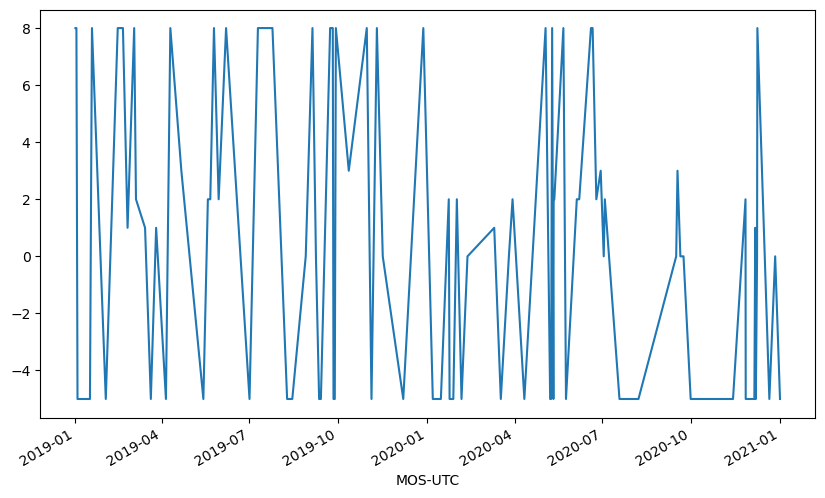

In [32]:
# Plot of 'OffsetUTC' against the index column
sales_data_2_viz['OffsetUTC'].plot(figsize=(10,6))

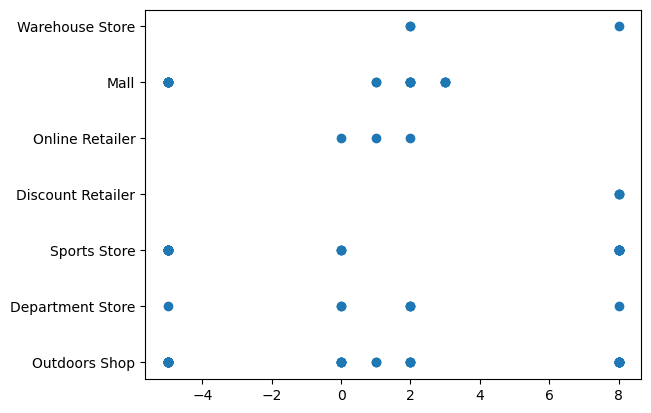

In [33]:
# Do a scatter plot of OffsetUTC against RetailerType
plt.scatter(sales_data_2_viz['OffsetUTC'], sales_data_2_viz['RetailerType'])

In [52]:
# Group By and sum the Sales Revenue
sales_data_2_viz.groupby('TimeZone')['Sales Revenue ($)'].sum()



TimeZone
Australia/West    4642.80
CET               6651.36
EET               4693.50
EST               9215.42
GMT               1266.51
Singapore          221.51
Name: Sales Revenue ($), dtype: float64

In [51]:
total_sales_revenue_by_timezone = sales_data_2_viz.groupby('TimeZone')['Sales Revenue ($)'].sum()

total_sales_revenue_by_timezone_df = pd.DataFrame(total_sales_revenue_by_timezone)
total_sales_revenue_by_timezone_df


,Sales Revenue ($)
TimeZone,
Australia/West,4642.80
CET,6651.36
EET,4693.50
EST,9215.42
GMT,1266.51
Singapore,221.51
